# 02 — From a spread to a trading signal

Once a pair looks cointegrated, the spread is the thing we actually trade. This notebook builds the four
pieces that turn a spread into positions: the **hedge ratio**, the **half-life** of mean reversion (how
fast the spread snaps back), the **z-score** (how stretched it is right now), and the **entry/exit rule**.
I use MA/V (Mastercard vs. Visa) — the pair that turns out to work later on.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statarb import config, data, signals

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
BLUE, PURPLE, VERM, GREY = "#0072B2", "#CC79A7", "#D55E00", "#8A8F98"

px = data.align_prices(pd.read_csv("../data/pairs.csv", index_col=0, parse_dates=True))
y, x = np.log(px["MA"]), np.log(px["V"])

## Hedge ratio and spread

Regress one log price on the other; the slope $\beta$ says how many units of $x$ hedge one unit of $y$,
and the residual is the spread
$$s_t = y_t - (\alpha + \beta x_t).$$
This is the same regression the cointegration test used — here I keep the residual rather than its
p-value.

In [2]:
beta = signals.hedge_ratio(y, x)
s = signals.spread(y, x)
print(f"hedge ratio beta = {beta:.3f}")
print(f"spread mean = {s.mean():.4f},  std = {s.std():.4f}")

hedge ratio beta = 1.142
spread mean = 0.0000,  std = 0.0611


## Half-life of mean reversion

Model the spread as an AR(1) / Ornstein–Uhlenbeck process and regress its change on its level,
$$\Delta s_t = a + b\, s_{t-1} + \varepsilon_t.$$
A mean-reverting spread has $b<0$, and the time to close half the gap to the mean is
$$\text{half-life} = -\frac{\ln 2}{b}.$$
It tells me the horizon I am trading on — too long and the spread is barely reverting.

In [3]:
hl = signals.half_life(s)
print(f"half-life = {hl:.0f} trading days  (~{hl/21:.1f} months)")

half-life = 69 trading days  (~3.3 months)


## Z-score and the entry/exit rule

Standardise the spread to a z-score, $z_t = (s_t - \mu_s)/\sigma_s$, so "how stretched" is measured in
standard deviations. The rule enters when $|z|$ is large and exits near the mean, with a gap between the
two bands (**hysteresis**) so the position does not flip on every small wiggle: go short the spread when
$z>$ entry, long when $z<-$ entry, and flatten once $z$ falls back inside the exit band.

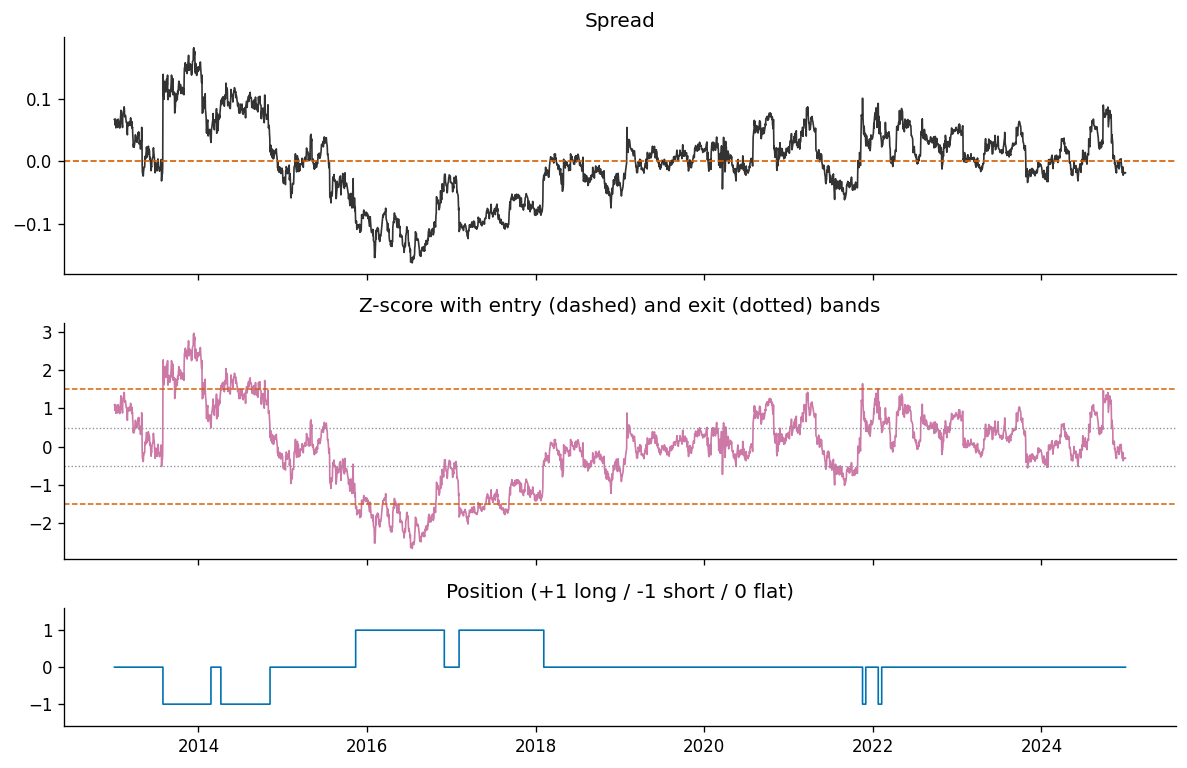

trades taken: 12


In [4]:
z = signals.zscore(s)
entry, exit_ = 1.5, 0.5
pos = signals.generate_signals(z.reset_index(drop=True), entry, exit_); pos.index = z.index

fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 2, 1]})
a1.plot(s.index, s, color="#333", lw=1.0); a1.axhline(s.mean(), ls="--", color=VERM, lw=1)
a1.set_title("Spread")
a2.plot(z.index, z, color=PURPLE, lw=1.0)
for lv in (entry, -entry): a2.axhline(lv, ls="--", lw=0.9, color=VERM)
for lv in (exit_, -exit_): a2.axhline(lv, ls=":", lw=0.8, color=GREY)
a2.set_title("Z-score with entry (dashed) and exit (dotted) bands")
a3.plot(pos.index, pos, drawstyle="steps-post", color=BLUE, lw=1.0)
a3.set_ylim(-1.6, 1.6); a3.set_yticks([-1, 0, 1]); a3.set_title("Position (+1 long / -1 short / 0 flat)")
plt.tight_layout(); plt.show()
print(f"trades taken: {int((pos.diff().abs() > 0).sum())}")

A rolling z-score is available too (`zscore(s, window=...)`), which standardises against a trailing
window instead of the full sample — useful live, where the future mean is unknown. Either way the output
is the same: a stream of positions in $\{-1,0,+1\}$. The next notebook turns those positions into a
cost-aware, out-of-sample track record.